In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [2]:
df = pd.read_csv('../../../data/processed/land_dataset_final_v3_noisy_2.csv')

In [3]:
df

,address_subdivision,address_locality,address_line_2,h_id,price_per_m2,land_area,price,longitude,latitude,near_Koh_Pich_in_km,...,f_road,f_secondary,f_service,f_steps,f_tertiary,f_track,f_trunk,f_trunk_link,f_unclassified,f_unused
0,Phnom Penh,Mean Chey,Stueng Mean Chey,8865846a91fffff,3249.773855,52.849329,1.717484e+05,104.883100,11.552932,5.751517,...,0,1,1,0,0,0,0,0,0,0
1,Phnom Penh,Chamkar Mon,Phsar Daeum Thkov,8865846acbfffff,2357.960918,179.682029,4.236832e+05,104.915003,11.528833,2.951587,...,0,0,0,0,0,0,0,0,0,0
2,Phnom Penh,Saensokh,Phnom Penh Thmei,88658468cbfffff,3466.326691,139.038859,4.819541e+05,104.886163,11.586713,6.822753,...,0,0,1,0,0,0,0,0,0,0
3,Phnom Penh,Saensokh,Phnom Penh Thmei,8865846ab1fffff,2979.374452,161.920279,4.824211e+05,104.889529,11.575790,6.075819,...,0,0,0,0,0,0,0,0,0,0
4,Phnom Penh,Doun Penh,Chakto Mukh,8865846a39fffff,5133.654419,200.964577,1.031683e+06,104.958218,11.558388,0.811035,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9267,Phnom Penh,Chraoy Chongvar,Bak Kaeng,886586a699fffff,649.765695,180.608364,1.173531e+05,104.929226,11.701893,16.053352,...,0,0,0,0,0,0,0,0,0,0
9268,Phnom Penh,Chraoy Chongvar,Preaek Ta Sek,8865846995fffff,158.350974,209.621191,3.319372e+04,104.899855,11.667508,13.149428,...,0,0,0,0,0,0,0,0,0,0
9269,Phnom Penh,Praek Pnov,Ponsang,8865846d85fffff,281.534392,133.551777,3.759942e+04,104.756877,11.633307,22.017518,...,0,0,0,0,0,0,0,0,0,0
9270,Phnom Penh,Pur SenChey,Kantaok,8865846e31fffff,511.506551,229.191548,1.172330e+05,104.785133,11.523526,16.977042,...,0,0,1,0,0,0,0,0,0,0


In [194]:
X = df.drop(columns=["price_per_m2", "address_locality", "address_subdivision", "price", "longitude", "latitude", "geometry"])
# X = X.drop(columns=["mean_price_per_m2", "max_price_per_m2", "median_price_per_m2", "min_price_per_m2"])
y = df["price_per_m2"]

In [195]:
X

,address_line_2,h_id,land_area,near_Koh_Pich_in_km,Koh_Pich_nearest,Koh_Pich_1_2km,Koh_Pich_2_3km,Koh_Pich_3_5km,Koh_Pich_5_10km,near_Russian_Market_in_km,...,f_road,f_secondary,f_service,f_steps,f_tertiary,f_track,f_trunk,f_trunk_link,f_unclassified,f_unused
0,Stueng Mean Chey,8865846a91fffff,52.849329,5.751517,0,0,0,0,1,3.085829,...,0,1,1,0,0,0,0,0,0,0
1,Phsar Daeum Thkov,8865846acbfffff,179.682029,2.951587,0,0,0,1,0,1.043521,...,0,0,0,0,0,0,0,0,0,0
2,Phnom Penh Thmei,88658468cbfffff,139.038859,6.822753,0,0,0,0,1,4.861459,...,0,0,1,0,0,0,0,0,0,0
3,Phnom Penh Thmei,8865846ab1fffff,161.920279,6.075819,0,0,0,0,1,4.097750,...,0,0,0,0,0,0,0,0,0,0
4,Chakto Mukh,8865846a39fffff,200.964577,0.811035,0,1,0,0,0,5.106891,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9267,Bak Kaeng,886586a699fffff,180.608364,16.053352,0,0,0,0,0,16.881548,...,0,0,0,0,0,0,0,0,0,0
9268,Preaek Ta Sek,8865846995fffff,209.621191,13.149428,0,0,0,0,0,13.815990,...,0,0,0,0,0,0,0,0,0,0
9269,Ponsang,8865846d85fffff,133.551777,22.017518,0,0,0,0,0,18.802672,...,0,0,0,0,0,0,0,0,0,0
9270,Kantaok,8865846e31fffff,229.191548,16.977042,0,0,0,0,0,13.862418,...,0,0,1,0,0,0,0,0,0,0


In [196]:
# X = X.drop(columns=[col for col in X.columns if "5km" in col.lower() or "3km" in col.lower() or "in_km" in col.lower() or "2km" in col.lower()])

In [197]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['address_line_2', 'h_id']


In [198]:
X_original_categorical = X[categorical_cols].copy()

In [199]:
label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    
    # Create mapping dictionary
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Encoding map for {col}: {mapping}")

# Save mappings to file (for future use)
import joblib
joblib.dump(label_encoders, '../../../data/processed/label_encoders_v2.pkl')


Encoding map for address_line_2: {'Bak Kaeng': 0, 'Boeng Kak Ti Muoy': 1, 'Boeng Kak Ti Pir': 2, 'Boeng Keng Kang Ti Bei': 3, 'Boeng Keng Kang Ti Muoy': 4, 'Boeng Keng Kang Ti Pir': 5, 'Boeng Proluet': 6, 'Boeng Reang': 7, 'Boeng Salang': 8, 'Boeng Thum': 9, 'Boeng Trabaek': 10, 'Boeng Tumpun': 11, 'Chak Angrae Kraom': 12, 'Chak Angrae Leu': 13, 'Chakto Mukh': 14, 'Chaom Chau': 15, 'Chbar Ampov Ti Pir': 16, 'Cheung Aek': 17, 'Chey Chummeah': 18, 'Chhbar Ampov Ti Muoy': 19, 'Chrang Chamreh Ti Muoy': 20, 'Chrang Chamreh Ti Pir': 21, 'Chrouy Changvar': 22, 'Dangkao': 23, 'Kakab': 24, 'Kamboul': 25, 'Kantaok': 26, 'Kaoh Dach': 27, 'Kbal Kaoh': 28, 'Khmuonh': 29, 'Kilomaetr Lekh Prammuoy': 30, 'Kong Noy': 31, 'Kouk Roka': 32, 'Krang Pongro': 33, 'Krang Thnong': 34, 'Mittapheap': 35, 'Monourom': 36, 'Nirouth': 37, 'Olympic': 38, 'Ou Ruessei Ti Bei': 39, 'Ou Ruessei Ti Buon': 40, 'Ou Ruessei Ti Muoy': 41, 'Ou Ruessei Ti Pir': 42, 'Ovlaok': 43, 'Phleung Chheh Roteh': 44, 'Phnom Penh Thmei': 45

['../../../data/processed/label_encoders_v2.pkl']

In [ ]:
selector = VarianceThreshold(threshold=0.01)
X_variance = selector.fit_transform(X_encoded)
selected_features_variance = X_encoded.columns[selector.get_support()]
print(f"Features after variance threshold: {list(selected_features_variance)}")
print(f"Removed features: {list(set(X_encoded.columns) - set(selected_features_variance))}")
X_filtered = pd.DataFrame(X_variance, columns=selected_features_variance)


Features after variance threshold: ['address_line_2', 'h_id', 'land_area', 'near_Koh_Pich_in_km', 'Koh_Pich_1_2km', 'Koh_Pich_2_3km', 'Koh_Pich_3_5km', 'Koh_Pich_5_10km', 'near_Russian_Market_in_km', 'Russian_Market_nearest', 'Russian_Market_1_2km', 'Russian_Market_2_3km', 'Russian_Market_3_5km', 'Russian_Market_5_10km', 'near_AEON_Mall_1_in_km', 'AEON_Mall_1_nearest', 'AEON_Mall_1_1_2km', 'AEON_Mall_1_2_3km', 'AEON_Mall_1_3_5km', 'AEON_Mall_1_5_10km', 'near_AEON_Mall_2_in_km', 'AEON_Mall_2_1_2km', 'AEON_Mall_2_2_3km', 'AEON_Mall_2_3_5km', 'AEON_Mall_2_5_10km', 'near_AEON_Mall_3_in_km', 'AEON_Mall_3_2_3km', 'AEON_Mall_3_3_5km', 'AEON_Mall_3_5_10km', 'near_Bassac_Lane_in_km', 'Bassac_Lane_nearest', 'Bassac_Lane_1_2km', 'Bassac_Lane_2_3km', 'Bassac_Lane_3_5km', 'Bassac_Lane_5_10km', 'near_Koh_Norea_in_km', 'Koh_Norea_1_2km', 'Koh_Norea_2_3km', 'Koh_Norea_3_5km', 'Koh_Norea_5_10km', 'near_Camko_City_in_km', 'Camko_City_nearest', 'Camko_City_1_2km', 'Camko_City_2_3km', 'Camko_City_3_5km', 

In [201]:
corr_matrix = X_filtered.corr().abs()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
high_corr = (corr_matrix.mask(mask) >= 0.9).any()
features_to_remove = high_corr[high_corr].index.tolist()
X_uncorr = X_filtered.drop(columns=features_to_remove)
print(f"Removed correlated features: {features_to_remove}")
print(f"Features after correlation filter: {X_uncorr.columns.tolist()}")

Removed correlated features: ['near_Koh_Pich_in_km', 'near_Russian_Market_in_km', 'near_AEON_Mall_1_in_km', 'near_AEON_Mall_2_in_km', 'near_Bassac_Lane_in_km', 'Bassac_Lane_5_10km', 'near_Koh_Norea_in_km', 'near_Camko_City_in_km', 'near_Olympic_Stadium_in_km', 'near_Phsar_Tmey_in_km', 'Phsar_Tmey_5_10km', 'near_Boeng_Keng_Kang_1_in_km', 'near_Wat_Phnom_in_km', 'Wat_Phnom_5_10km', 'near_Chroy_Changvar_Bridge_in_km', 'near_Vattanac_Tower_in_km', 'near_Royal_Palace_in_km', 'Royal_Palace_5_10km', 'near_Sisowath_Riverside_Park_in_km', 'Sisowath_Riverside_Park_5_10km', 'near_Phsar_Chas_in_km', 'Phsar_kandal_3_5km', 'n_cafe_5km', 'n_cafe_in_1km_to_2km', 'n_cafe_in_2km_to_3km', 'n_cafe_in_3km_to_5km', 'n_gas_station_5km', 'n_gas_station_in_1km_to_2km', 'n_gas_station_in_2km_to_3km', 'n_gas_station_in_3km_to_5km', 'n_hospital_5km', 'n_hospital_in_1km_to_2km', 'n_hospital_in_2km_to_3km', 'n_hospital_in_3km_to_5km', 'n_hotel_5km', 'nearest_hotel', 'n_hotel_in_1km', 'n_hotel_in_1km_to_2km', 'n_hot

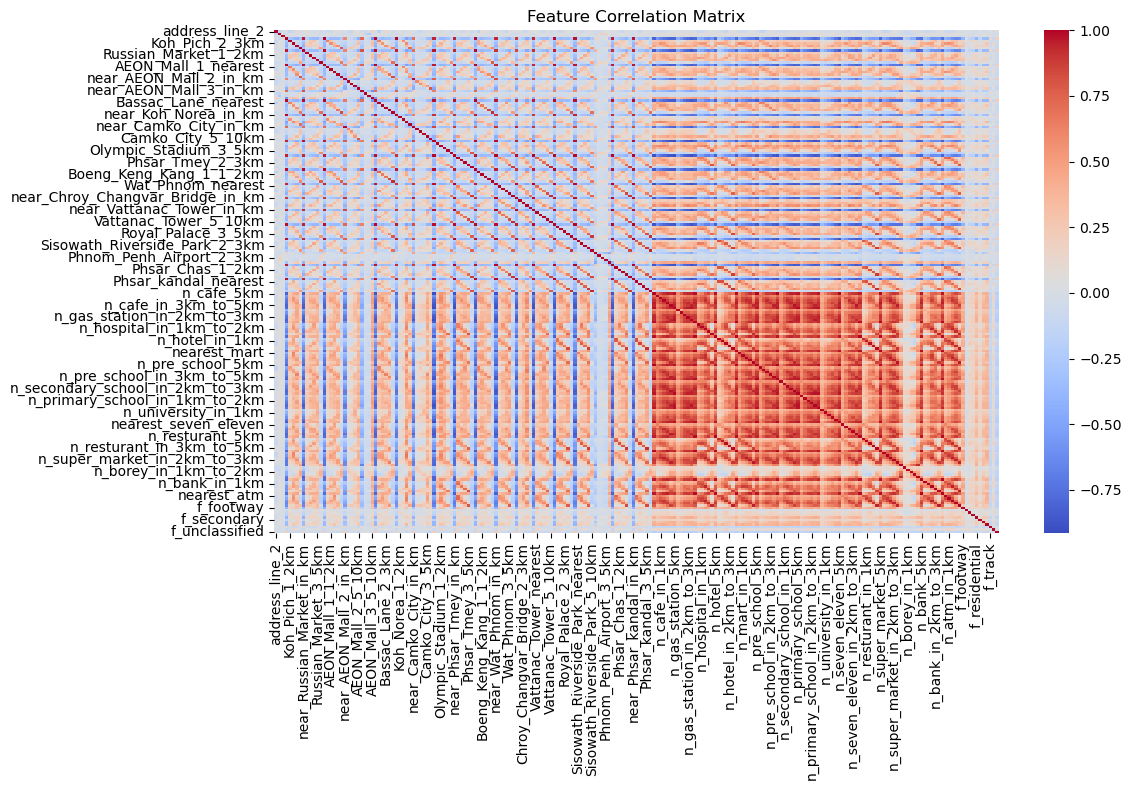

In [202]:
plt.figure(figsize=(12, 8))
sns.heatmap(X_filtered.corr(), cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [203]:
mi_scores = mutual_info_regression(X_uncorr, y)
mi_series = pd.Series(mi_scores, index=X_uncorr.columns).sort_values(ascending=False)
top_mi_features = mi_series.head(30).index.tolist()
print("Top features by Mutual Information:", top_mi_features)

Top features by Mutual Information: ['address_line_2', 'h_id', 'n_university_in_3km_to_5km', 'near_Phsar_kandal_in_km', 'n_atm_in_3km_to_5km', 'n_atm_5km', 'n_university_in_2km_to_3km', 'n_atm_in_2km_to_3km', 'n_atm_in_1km_to_2km', 'n_university_in_1km_to_2km', 'n_cafe_in_1km', 'n_super_market_in_1km', 'n_borey_in_3km_to_5km', 'n_atm_in_1km', 'n_primary_school_in_1km', 'n_pre_school_in_1km', 'n_mart_in_1km', 'n_secondary_school_in_1km', 'n_university_in_1km', 'n_gas_station_in_1km', 'n_hospital_in_1km', 'nearest_cafe', 'near_AEON_Mall_3_in_km', 'nearest_atm', 'nearest_super_market', 'near_Phnom_Penh_Airport_in_km', 'n_resturant_in_1km', 'nearest_mart', 'n_seven_eleven_in_1km', 'n_bank_in_1km']


In [204]:
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=rfr, n_features_to_select=20)
rfe.fit(X_uncorr[top_mi_features], y)
rfe_selected_features = X_uncorr[top_mi_features].columns[rfe.support_].tolist()
print("RFE-selected features:", rfe_selected_features)

RFE-selected features: ['address_line_2', 'h_id', 'n_university_in_3km_to_5km', 'near_Phsar_kandal_in_km', 'n_atm_in_3km_to_5km', 'n_atm_5km', 'n_university_in_2km_to_3km', 'n_atm_in_2km_to_3km', 'n_atm_in_1km_to_2km', 'n_cafe_in_1km', 'n_super_market_in_1km', 'n_borey_in_3km_to_5km', 'n_atm_in_1km', 'n_pre_school_in_1km', 'n_mart_in_1km', 'n_gas_station_in_1km', 'n_hospital_in_1km', 'near_AEON_Mall_3_in_km', 'near_Phnom_Penh_Airport_in_km', 'n_resturant_in_1km']


In [205]:
lasso = LassoCV(cv=5, random_state=42).fit(X_uncorr[top_mi_features], y)
lasso_selected_features = X_uncorr[top_mi_features].columns[lasso.coef_ != 0].tolist()
print("Lasso-selected features:", lasso_selected_features)

Lasso-selected features: ['address_line_2', 'h_id', 'n_university_in_3km_to_5km', 'near_Phsar_kandal_in_km', 'n_atm_in_3km_to_5km', 'n_atm_5km', 'n_atm_in_1km_to_2km', 'n_borey_in_3km_to_5km', 'n_atm_in_1km', 'nearest_atm']


In [206]:
rfr.fit(X_uncorr[top_mi_features], y)
rf_importances = pd.Series(rfr.feature_importances_, index=top_mi_features)
top_rf_features = rf_importances.sort_values(ascending=False).head(20).index.tolist()
print("Top RandomForest features:", top_rf_features)

Top RandomForest features: ['n_university_in_3km_to_5km', 'n_resturant_in_1km', 'address_line_2', 'n_university_in_2km_to_3km', 'n_atm_5km', 'near_AEON_Mall_3_in_km', 'near_Phnom_Penh_Airport_in_km', 'n_atm_in_1km', 'near_Phsar_kandal_in_km', 'n_atm_in_3km_to_5km', 'h_id', 'n_atm_in_1km_to_2km', 'n_super_market_in_1km', 'n_borey_in_3km_to_5km', 'n_atm_in_2km_to_3km', 'n_hospital_in_1km', 'n_cafe_in_1km', 'n_pre_school_in_1km', 'n_mart_in_1km', 'n_gas_station_in_1km']


In [207]:
final_selected_features = list(set(rfe_selected_features) | set(lasso_selected_features) | set(top_rf_features))
print("Final selected features (union):", final_selected_features)

X_selected = X_uncorr[final_selected_features]

Final selected features (union): ['n_atm_in_1km', 'n_university_in_2km_to_3km', 'n_gas_station_in_1km', 'n_borey_in_3km_to_5km', 'near_Phnom_Penh_Airport_in_km', 'near_Phsar_kandal_in_km', 'n_cafe_in_1km', 'address_line_2', 'n_university_in_3km_to_5km', 'n_mart_in_1km', 'n_pre_school_in_1km', 'nearest_atm', 'h_id', 'n_super_market_in_1km', 'n_atm_in_2km_to_3km', 'n_atm_in_3km_to_5km', 'n_atm_5km', 'near_AEON_Mall_3_in_km', 'n_atm_in_1km_to_2km', 'n_hospital_in_1km', 'n_resturant_in_1km']


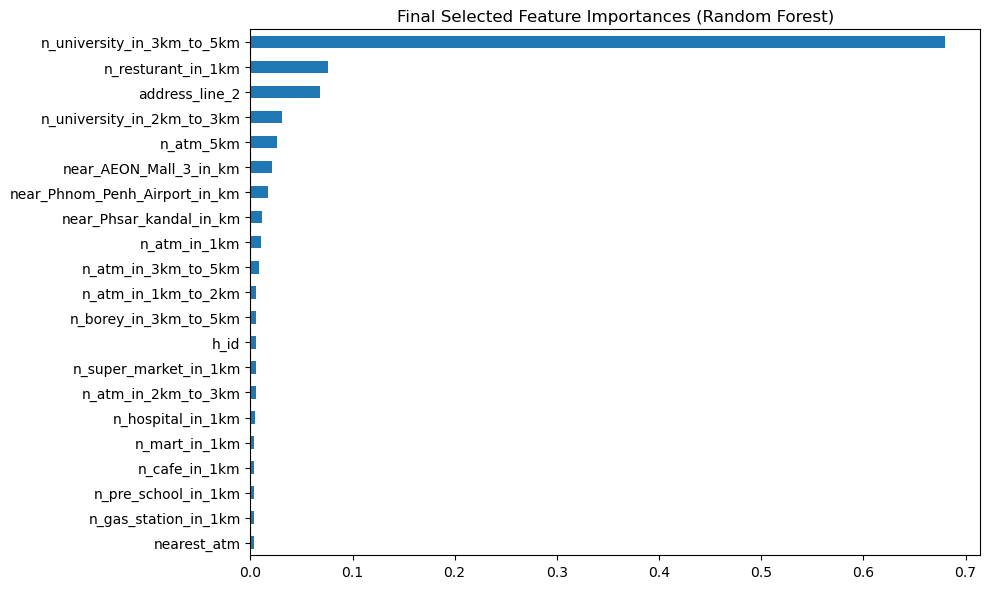

In [208]:
final_rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_rf_model.fit(X_selected, y)
importances = pd.Series(final_rf_model.feature_importances_, index=X_selected.columns)

plt.figure(figsize=(10, 6))
importances.sort_values(ascending=True).plot(kind='barh')
plt.title("Final Selected Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

In [209]:

print("Permutation Importance:")
print(importances.sort_values(ascending=False))

Permutation Importance:
n_university_in_3km_to_5km       0.680175
n_resturant_in_1km               0.076068
address_line_2                   0.067881
n_university_in_2km_to_3km       0.030865
n_atm_5km                        0.025605
near_AEON_Mall_3_in_km           0.020786
near_Phnom_Penh_Airport_in_km    0.017676
near_Phsar_kandal_in_km          0.011145
n_atm_in_1km                     0.010793
n_atm_in_3km_to_5km              0.008906
n_atm_in_1km_to_2km              0.005708
n_borey_in_3km_to_5km            0.005440
h_id                             0.005324
n_super_market_in_1km            0.005263
n_atm_in_2km_to_3km              0.005198
n_hospital_in_1km                0.004553
n_mart_in_1km                    0.004054
n_cafe_in_1km                    0.003851
n_pre_school_in_1km              0.003690
n_gas_station_in_1km             0.003599
nearest_atm                      0.003421
dtype: float64


In [210]:
importances

n_atm_in_1km                     0.010793
n_university_in_2km_to_3km       0.030865
n_gas_station_in_1km             0.003599
n_borey_in_3km_to_5km            0.005440
near_Phnom_Penh_Airport_in_km    0.017676
near_Phsar_kandal_in_km          0.011145
n_cafe_in_1km                    0.003851
address_line_2                   0.067881
n_university_in_3km_to_5km       0.680175
n_mart_in_1km                    0.004054
n_pre_school_in_1km              0.003690
nearest_atm                      0.003421
h_id                             0.005324
n_super_market_in_1km            0.005263
n_atm_in_2km_to_3km              0.005198
n_atm_in_3km_to_5km              0.008906
n_atm_5km                        0.025605
near_AEON_Mall_3_in_km           0.020786
n_atm_in_1km_to_2km              0.005708
n_hospital_in_1km                0.004553
n_resturant_in_1km               0.076068
dtype: float64

In [211]:
# corr = df[['median_price_per_m2', 'price_per_m2']].corr().iloc[0, 1]
# print(f"Correlation between population and price_per_m2: {corr:.4f}")


In [212]:
top_features_final = importances.head(20).index.tolist()
X_final = X[top_features_final]

In [213]:
final_df = pd.concat([X_final, y], axis=1)
final_df.to_csv('../../../data/preprocessed/selected_features_dataset_3.csv', index=False)

In [214]:
# Identify which categorical features are in the selected features
selected_categorical = [col for col in top_features_final if col in categorical_cols]
selected_numerical = [col for col in top_features_final if col not in categorical_cols]

print("Selected categorical features for one-hot encoding:", selected_categorical)
print("Selected numerical features:", selected_numerical)

# Initialize OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform only on selected categorical features
if selected_categorical:
    # Get the original categorical data for selected features
    X_cat_selected = X_original_categorical[selected_categorical]
    
    # One-hot encode
    X_ohe = ohe.fit_transform(X_cat_selected)
    
    # Get feature names
    ohe_feature_names = ohe.get_feature_names_out(selected_categorical)
    
    # Create DataFrame
    X_ohe_df = pd.DataFrame(X_ohe, columns=ohe_feature_names)
    
    # Save one-hot encoder
    joblib.dump(ohe, '../../../data/preprocessed/onehot_encoder_v2_2.pkl')
    print("OneHotEncoder saved")
else:
    X_ohe_df = pd.DataFrame()
    print("No categorical features selected for one-hot encoding")

# Combine with numerical features
X_num_selected = X[selected_numerical].reset_index(drop=True)

if not X_ohe_df.empty:
    X_onehot = pd.concat([X_num_selected, X_ohe_df], axis=1)
else:
    X_onehot = X_num_selected

Selected categorical features for one-hot encoding: ['address_line_2', 'h_id']
Selected numerical features: ['n_atm_in_1km', 'n_university_in_2km_to_3km', 'n_gas_station_in_1km', 'n_borey_in_3km_to_5km', 'near_Phnom_Penh_Airport_in_km', 'near_Phsar_kandal_in_km', 'n_cafe_in_1km', 'n_university_in_3km_to_5km', 'n_mart_in_1km', 'n_pre_school_in_1km', 'nearest_atm', 'n_super_market_in_1km', 'n_atm_in_2km_to_3km', 'n_atm_in_3km_to_5km', 'n_atm_5km', 'near_AEON_Mall_3_in_km', 'n_atm_in_1km_to_2km', 'n_hospital_in_1km']
OneHotEncoder saved


In [215]:
selected_categorical = [col for col in top_features_final if col in categorical_cols]
print("Selected categorical features for one-hot encoding:", selected_categorical)

Selected categorical features for one-hot encoding: ['address_line_2', 'h_id']


In [216]:
selected_label_encoders = {col: label_encoders[col] for col in selected_categorical if col in label_encoders}
import joblib
joblib.dump(selected_label_encoders, '../../../data/processed/label_encoders_selected_v2_2.pkl')

['../../../data/processed/label_encoders_selected_v2_2.pkl']

In [217]:
for col, le in selected_label_encoders.items():
    unique_values = list(le.classes_)
    print(f"{col}: {len(unique_values)} unique values")
    print(f"  Values: {unique_values}")

address_line_2: 96 unique values
  Values: ['Bak Kaeng', 'Boeng Kak Ti Muoy', 'Boeng Kak Ti Pir', 'Boeng Keng Kang Ti Bei', 'Boeng Keng Kang Ti Muoy', 'Boeng Keng Kang Ti Pir', 'Boeng Proluet', 'Boeng Reang', 'Boeng Salang', 'Boeng Thum', 'Boeng Trabaek', 'Boeng Tumpun', 'Chak Angrae Kraom', 'Chak Angrae Leu', 'Chakto Mukh', 'Chaom Chau', 'Chbar Ampov Ti Pir', 'Cheung Aek', 'Chey Chummeah', 'Chhbar Ampov Ti Muoy', 'Chrang Chamreh Ti Muoy', 'Chrang Chamreh Ti Pir', 'Chrouy Changvar', 'Dangkao', 'Kakab', 'Kamboul', 'Kantaok', 'Kaoh Dach', 'Kbal Kaoh', 'Khmuonh', 'Kilomaetr Lekh Prammuoy', 'Kong Noy', 'Kouk Roka', 'Krang Pongro', 'Krang Thnong', 'Mittapheap', 'Monourom', 'Nirouth', 'Olympic', 'Ou Ruessei Ti Bei', 'Ou Ruessei Ti Buon', 'Ou Ruessei Ti Muoy', 'Ou Ruessei Ti Pir', 'Ovlaok', 'Phleung Chheh Roteh', 'Phnom Penh Thmei', 'Phsar Chas', 'Phsar Daeum Kor', 'Phsar Daeum Thkov', 'Phsar Depou Ti Bei', 'Phsar Depou Ti Muoy', 'Phsar Depou Ti Pir', 'Phsar Kandal Ti Muoy', 'Phsar Kandal Ti 

In [218]:
# Create final one-hot encoded dataset
final_df_onehot = pd.concat([X_onehot, y.reset_index(drop=True)], axis=1)
final_df_onehot.to_csv('../../../data/preprocessed/selected_features_onehot_encoded_2.csv', index=False)

In [219]:
# Use label-encoded features only for selected categorical columns
X_label_encoded_final = X[selected_numerical].copy()  # Start with selected numerical features

for col in selected_categorical:
    le = selected_label_encoders[col]
    X_label_encoded_final[col] = le.transform(X[col])

# Reorder to match original top_features_final order
X_label_encoded_final = X_label_encoded_final.reindex(columns=top_features_final)

# Combine with target
final_df_label = pd.concat([X_label_encoded_final, y.reset_index(drop=True)], axis=1)

# Save to CSV
final_df_label.to_csv('../../../data/preprocessed/selected_features_label_encoded_2.csv', index=False)
print("Label Encoded dataset saved.")

Label Encoded dataset saved.


In [220]:
# # %%
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.linear_model import LassoCV
# import joblib

# # %%
# def apply_vss(df, target_column, drop_columns, variance_threshold=0.01, corr_threshold=0.9, mi_top_n=30, rfe_features=20, rf_top_n=20):
#     # Separate features and target
#     X = df.drop(columns=drop_columns)
#     y = df[target_column]

#     # Label Encoding for categorical features
#     categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
#     label_encoders = {}
#     for col in categorical_cols:
#         le = LabelEncoder()
#         X[col] = le.fit_transform(X[col])
#         label_encoders[col] = le

#     # Variance Threshold
#     selector = VarianceThreshold(threshold=variance_threshold)
#     X_var = selector.fit_transform(X)
#     selected_features = X.columns[selector.get_support()]
#     X = pd.DataFrame(X_var, columns=selected_features)

#     # Remove highly correlated features
#     corr_matrix = X.corr().abs()
#     upper = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
#     to_drop = [col for i, col in enumerate(corr_matrix.columns)
#                if any(corr_matrix.iloc[i, :i] > corr_threshold)]
#     X_uncorr = X.drop(columns=to_drop)

#     # Mutual Information
#     mi_scores = mutual_info_regression(X_uncorr, y)
#     mi_series = pd.Series(mi_scores, index=X_uncorr.columns).sort_values(ascending=False)
#     top_mi_features = mi_series.head(mi_top_n).index.tolist()

#     # RFE
#     rfr = RandomForestRegressor(n_estimators=100, random_state=42)
#     rfe = RFE(estimator=rfr, n_features_to_select=rfe_features)
#     rfe.fit(X_uncorr[top_mi_features], y)
#     rfe_features = X_uncorr[top_mi_features].columns[rfe.support_].tolist()

#     # Lasso
#     lasso = LassoCV(cv=5, random_state=42).fit(X_uncorr[top_mi_features], y)
#     lasso_features = X_uncorr[top_mi_features].columns[lasso.coef_ != 0].tolist()

#     # Random Forest Importance
#     rfr.fit(X_uncorr[top_mi_features], y)
#     rf_importances = pd.Series(rfr.feature_importances_, index=top_mi_features)
#     rf_features = rf_importances.sort_values(ascending=False).head(rf_top_n).index.tolist()

#     # Final selected features (union)
#     final_features = list(set(rfe_features) | set(lasso_features) | set(rf_features))
#     X_final = X_uncorr[final_features]

#     return X_final, y, final_features, label_encoders

# # %%
# def encode_selected_features(X, categorical_cols, label_encoders, method='label'):
#     if method == 'label':
#         for col in categorical_cols:
#             le = label_encoders[col]
#             known_classes = set(le.classes_)
#             X[col] = X[col].apply(lambda x: le.transform([x])[0] if x in known_classes else -1)
#         return X

# # %%
# # Load your dataset
# df = pd.read_csv('../../../data/processed/land_dataset_final_v3.csv')

# # Columns to drop (not useful or redundant)
# drop_cols = ["price_per_m2", "address_locality", "address_subdivision", "price", "longitude", "latitude", "geometry"]

# # Apply VSS pipeline
# X_final, y_final, selected_features, label_encoders = apply_vss(df, target_column="price_per_m2", drop_columns=drop_cols)

# # Save base dataset with selected features
# final_df = pd.concat([X_final, y_final], axis=1)
# final_df.to_csv('../../../data/preprocessed/selected_features_vss.csv', index=False)

# # Save label encoders for selected categorical features
# categorical_cols_in_final = [col for col in selected_features if col in df.select_dtypes(include=['object', 'category']).columns]
# selected_label_encoders = {col: label_encoders[col] for col in categorical_cols_in_final}
# joblib.dump(selected_label_encoders, '../../../data/processed/label_encoders_selected_vss.pkl')

# # Label Encoding
# X_label_encoded = encode_selected_features(X_final.copy(), categorical_cols_in_final, selected_label_encoders, method='label')
# final_label_df = pd.concat([X_label_encoded, y_final], axis=1)
# final_label_df.to_csv('../../../data/preprocessed/selected_features_label_encoded_vss.csv', index=False)

# # One-Hot Encoding
# X_onehot_encoded = encode_selected_features(X_final.copy(), categorical_cols_in_final, selected_label_encoders, method='onehot')
# final_onehot_df = pd.concat([X_onehot_encoded, y_final], axis=1)
# final_onehot_df.to_csv('../../../data/preprocessed/selected_features_onehot_encoded_vss.csv', index=False)